# 📊 Exercise 04 — Visualization

**Day 2 · Semi-guided**

**Part A** matplotlib — static charts for reports. **Part B** plotly — interactive maps for exploration.

Part A has starter code. Part B gives you the goal — you write the code.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

# TODO: Replace with your city slug and display name
CITY_SLUG = "Gràcia"       # <-- change this!
CITY_NAME = "Gràcia"   # <-- for chart titles

df = pd.read_csv(f"../data/clean_{CITY_SLUG}.csv")
print(f"Loaded {len(df)} rows")

Loaded 939 rows


---

### 🎨 Part A: matplotlib + seaborn (static charts)

#### Chart 1: Top 15 amenity types (pre-built — study how it works)

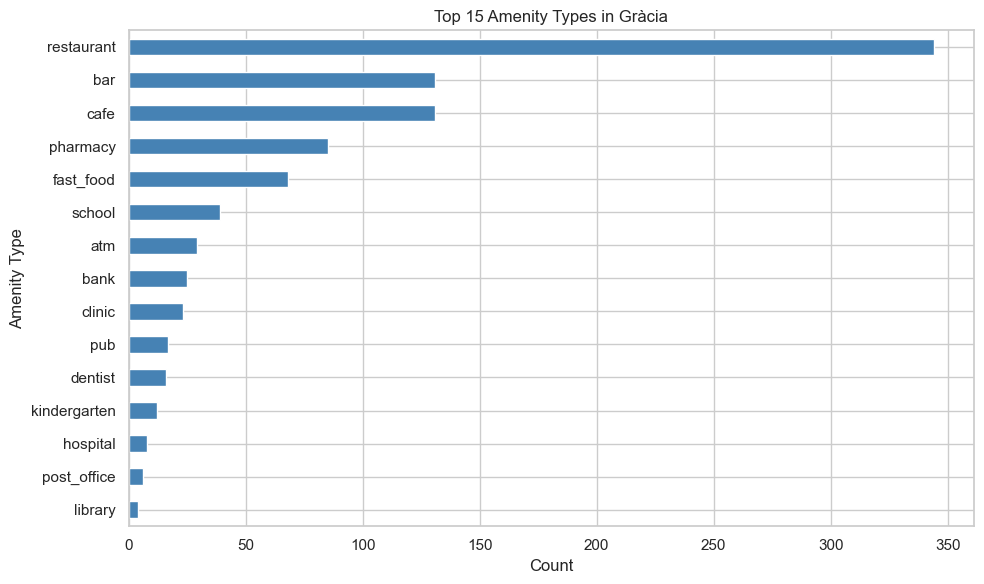

In [3]:
# Pre-built: horizontal bar chart of top 15 amenity types
top_amenities = df["amenity"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_amenities.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_ylabel("Amenity Type")
ax.set_title(f"Top 15 Amenity Types in {CITY_NAME}")
ax.invert_yaxis()  # Largest at top
plt.tight_layout()
plt.show()

#### Chart 2: Data completeness — **TODO** build this chart

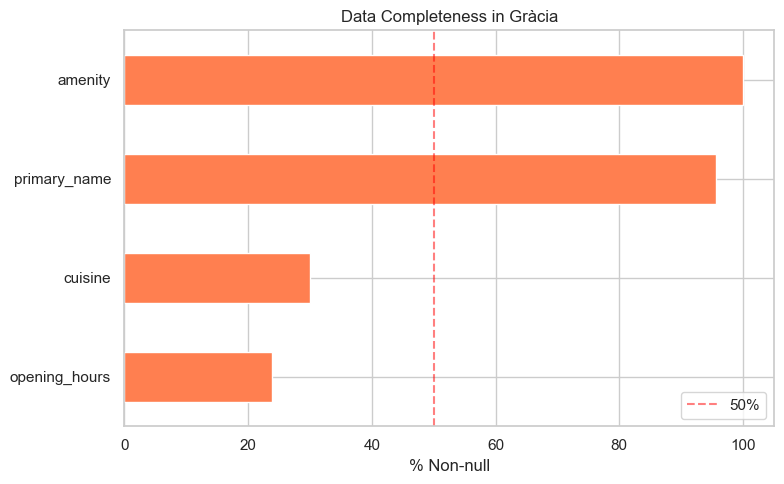

In [4]:
# TODO: Create a horizontal bar chart showing % non-null for key columns
# Key columns to check: amenity, primary_name, cuisine, opening_hours, phone, website

# Starter:
key_cols = ["amenity", "primary_name", "cuisine", "opening_hours"]
available_cols = [c for c in key_cols if c in df.columns]
completeness = df[available_cols].notna().mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
completeness.sort_values().plot(kind="barh", ax=ax, color="coral")
ax.set_xlabel("% Non-null")
ax.set_title(f"Data Completeness in {CITY_NAME}")
ax.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50%")
ax.legend()
plt.tight_layout()
plt.show()

#### Chart 3: Cuisine distribution — **TODO** bar chart of top 10 `cuisine_clean`

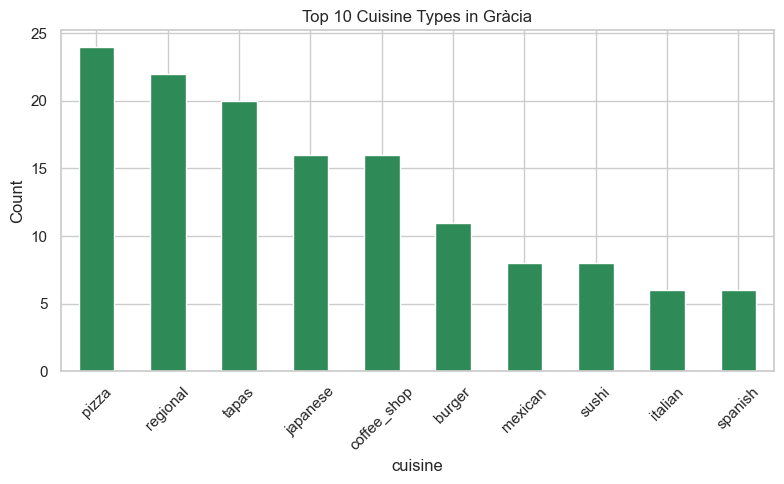

In [6]:
# TODO: Bar chart of top 10 cuisines
# Hint: similar pattern to Chart 1, but with df["cuisine_clean"].value_counts().head(10)
top_cuisines = df["cuisine"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_cuisines.plot(kind="bar", ax=ax, color="seagreen")
ax.set_ylabel("Count")
ax.set_title(f"Top 10 Cuisine Types in {CITY_NAME}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


---

### 🗺️ Part B: plotly (interactive maps)

You get the goal — you write the code. See [plotly express docs](https://plotly.com/python/plotly-express/).

#### Map 1: All amenities colored by `amenity_group`, hover shows name

Use `px.scatter_mapbox()` · `mapbox_style="carto-positron"` · `zoom=13`

In [7]:
# TODO: Create interactive map of all amenities

top_types = df["amenity"].value_counts().head(10).index.tolist()
df["amenity_group"] = df["amenity"].apply(lambda x: x if x in top_types else "other")

fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="amenity_group",
    hover_name="primary_name",
    hover_data=["amenity"],
    zoom=13,
    mapbox_style="carto-positron",
    title=f"Amenities in {CITY_NAME}",
)
fig.update_layout(margin=dict(l=0, r=0, t=30, b=0))
fig.show()


C:\Users\Lakzhmy\AppData\Local\Temp\ipykernel_31964\3537078092.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


#### Map 2: Restaurants/cafés/fast_food colored by `cuisine_clean`

In [11]:
# TODO: Create restaurant map colored by cuisine

restaurants = df[df["amenity"].isin(["restaurant", "cafe", "fast_food"])].copy()
restaurants["cuisine_display"] = restaurants["cuisine"].fillna("Unknown")

fig = px.scatter_mapbox(
    restaurants,
    lat="lat",
    lon="lon",
    color="cuisine_display",
    hover_name="primary_name",
    zoom=13,
    mapbox_style="carto-positron",
    title=f"Restaurants & Cafés in {CITY_NAME} by Cuisine",
)
fig.update_layout(margin=dict(l=0, r=0, t=30, b=0))
fig.show()


C:\Users\Lakzhmy\AppData\Local\Temp\ipykernel_31964\657587455.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


#### 💡 Chart 4: Your own question

Think of a question about your data and answer it with a chart. Write the question below, then build the chart.

*My question:*

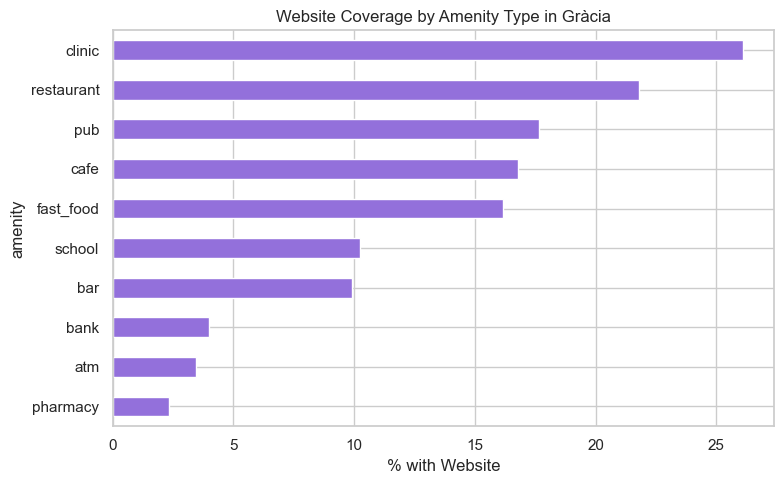

In [12]:
# Your chart answering the question above
# Question: Which amenity types are most likely to have a website listed?
top_types = df["amenity"].value_counts().head(10).index
subset = df[df["amenity"].isin(top_types)]
website_rate = subset.groupby("amenity")["website"].apply(lambda x: x.notna().mean() * 100)

fig, ax = plt.subplots(figsize=(8, 5))
website_rate.sort_values().plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_xlabel("% with Website")
ax.set_title(f"Website Coverage by Amenity Type in {CITY_NAME}")
plt.tight_layout()
plt.show()


---

✅ 3 static charts · ✅ 2 interactive maps · ✅ 1 chart answering your own question

Remember this code — you'll reuse it in your Streamlit app on Day 3.

**Next →** [Exercise 05 — Debugging](05_debugging.ipynb)

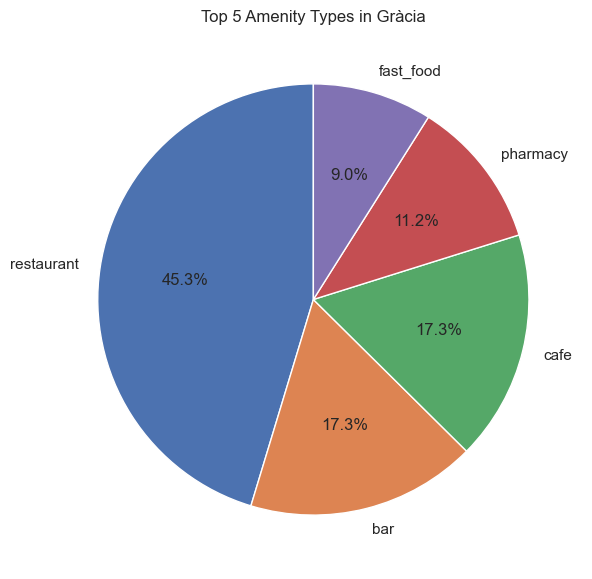

In [13]:
top5 = df["amenity"].value_counts().head(5)
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(top5, labels=top5.index, autopct="%1.1f%%", startangle=90)
ax.set_title(f"Top 5 Amenity Types in {CITY_NAME}")
plt.show()

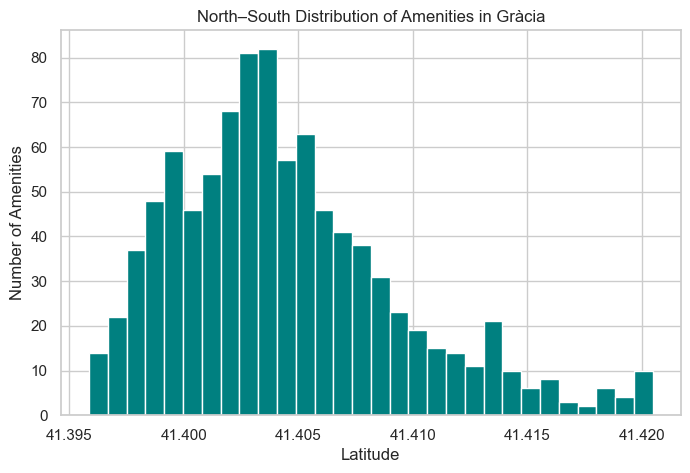

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["lat"], bins=30, color="teal", edgecolor="white")
ax.set_xlabel("Latitude")
ax.set_ylabel("Number of Amenities")
ax.set_title(f"North–South Distribution of Amenities in {CITY_NAME}")
plt.show()

In [15]:
fig = px.density_mapbox(
    df, lat="lat", lon="lon",
    radius=10, zoom=13,
    mapbox_style="carto-positron",
    title=f"Amenity Density in {CITY_NAME}",
)
fig.update_layout(margin=dict(l=0, r=0, t=30, b=0))
fig.show()


C:\Users\Lakzhmy\AppData\Local\Temp\ipykernel_31964\2948092621.py:1: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(
